## Conceptual Captions 3M MoLeJEPA Train Results

I trained a ~200m parameter model on cc3m (~1.5mm training examples) for 100 epochs. The results are recorded below.

Initial hypothesis was that SIGReg was fighting against the MSE causing it to increase, but looking at the contrastive model, I believe that the model is overfitting to the training data. Conclusion is that I need way more than just 1.5mm examples. Next step is to try using cc12m.

In [59]:
import json
import os

import pandas as pd
from plotly import express as px
from plotly import subplots

import dotenv

from mole_jepa import config, model_io

dotenv.load_dotenv()
ROOT = os.environ.get("CHECKPOINT_DIR")

In [33]:
def process_train_stats(train_stats: pd.DataFrame) -> pd.DataFrame:
    if "val_loss_reg_image" in train_stats:
        val_losses = pd.melt(
            train_stats,
            id_vars="epoch",
            value_vars=["val_loss_mse", "val_loss_reg_image", "val_loss_reg_text"],
            var_name="loss_type",
            value_name="loss",
        )
    else:
        val_losses = train_stats.copy()
        val_losses["loss_type"] = "InfoNCE"
        val_losses["loss"] = val_losses["val_loss"]
        val_losses = val_losses[["epoch", "loss_type", "loss"]].copy()

    return val_losses

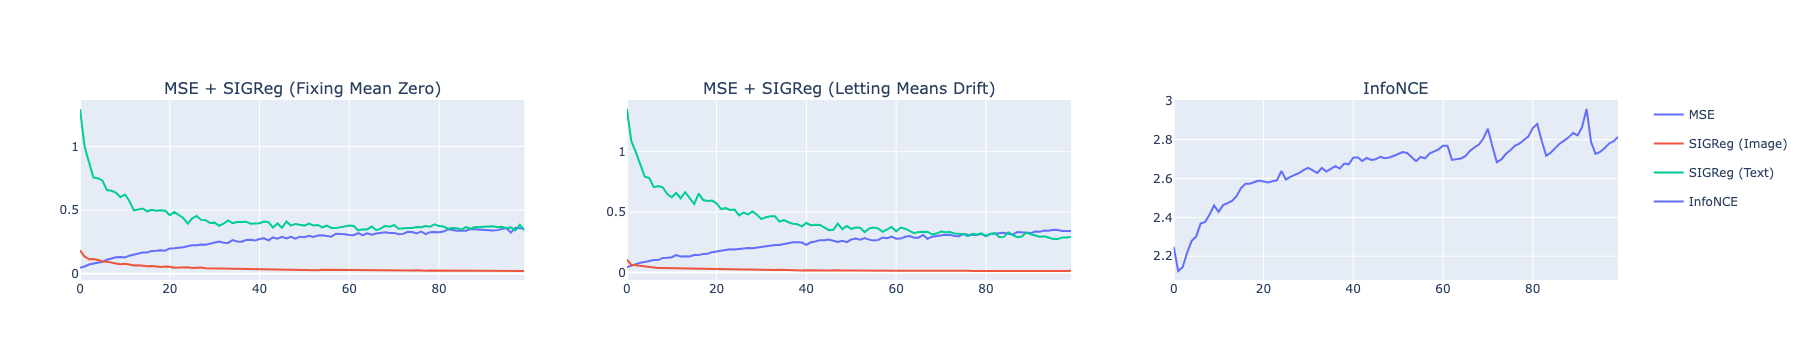

In [56]:
saved_models = model_io.list_models(ROOT)

all_subplots = []
titles = []

for model_info in saved_models:
    train_stats = pd.read_json(model_info.path / "stats.jsonl", lines=True)
    val_losses = process_train_stats(train_stats)

    if model_info.config.sigreg_demean:
        title = "MSE + SIGReg (Letting Means Drift)"
    elif model_info.config.contrastive:
        title = "InfoNCE"
       
    else:
        title = "MSE + SIGReg (Fixing Mean Zero)"

    titles.append(title)
    all_subplots.append(
        px.line(
            val_losses,
            x="epoch",
            y="loss",
            color="loss_type",
        ),
    )

fig = subplots.make_subplots(
    1,
    len(saved_models),
    subplot_titles=titles,
)

for i, plot in enumerate(all_subplots):
    for trace in plot.data:
        fig.add_trace(
            trace,
            row=1,
            col=i + 1,
        )

# Make sure no duplicates in legend
names = set()
fig.for_each_trace(
    lambda trace:
        trace.update(showlegend=False)
        if (trace.name in names) else names.add(trace.name))

# Legend name mapping
fig.for_each_trace(
    lambda t: t.update(
        name=t.name.replace("val_loss_mse", "MSE")
            .replace("val_loss_reg_image", "SIGReg (Image)")
            .replace("val_loss_reg_text", "SIGReg (Text)")
    ),
)

fig.show()